<a href="https://www.kaggle.com/code/soumadityamukh/idp-mamba-notebook?scriptVersionId=351803987" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# ============================================================
# CELL 1: Build mamba-ssm from source for PyTorch 2.10 + CUDA 12.8
# ============================================================
# This takes 5-8 minutes — be patient, it's compiling CUDA kernels!

import os
os.environ["TORCH_CUDA_ARCH_LIST"] = "7.5"   # Tesla T4 compute capability
os.environ["MAX_JOBS"] = "2"                   # Limit parallel jobs to avoid OOM during build

!pip install ninja packaging -q

# Step 1: Build causal-conv1d from source
!pip install causal-conv1d --no-build-isolation --no-cache-dir 2>&1 | tail -5

# Step 2: Build mamba-ssm from source  
!pip install mamba-ssm --no-build-isolation --no-cache-dir 2>&1 | tail -5

# Verify
try:
    from mamba_ssm import Mamba
    print("\n✅ mamba-ssm installed successfully!")
    import causal_conv1d
    print(f"✅ causal-conv1d version: {causal_conv1d.__version__}")
    print(f"✅ mamba-ssm ready to use")
except ImportError as e:
    print(f"\n❌ Import failed: {e}")

  Created wheel for causal-conv1d: filename=causal_conv1d-1.7.0-cp312-cp312-linux_x86_64.whl size=196558813 sha256=8e81f8c76435ad31aa41edc6c0c9d26de971a293b190183d2816da71547614d7
  Stored in directory: /tmp/pip-ephem-wheel-cache-4a3mxdga/wheels/6f/0b/1b/e063b1e314a5ff0783e450525921cb8f5c48fbb03639bad6ba
Successfully built causal-conv1d
  Created wheel for mamba-ssm: filename=mamba_ssm-2.3.2.post1-cp312-cp312-linux_x86_64.whl size=322288410 sha256=7a67070c1e7e99c95abd1319623f044e8a1b3fb46f774bfdea949f0a4fc79638
  Stored in directory: /tmp/pip-ephem-wheel-cache-p4xw2eii/wheels/da/67/03/99148d6eeaa4ec2855d71295ac83bcbc8ba7b41a2982992c63
Successfully built mamba-ssm

✅ mamba-ssm installed successfully!
✅ causal-conv1d version: 1.7.0
✅ mamba-ssm ready to use


In [2]:
# ============================================================
# CELL 2: Import all libraries
# ============================================================
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings('ignore')

# Check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available:  {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU:             {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory:      {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"Using device:    {device}")

PyTorch version: 2.10.0+cu128
CUDA available:  True
GPU:             Tesla T4
GPU Memory:      15.6 GB
Using device:    cuda


In [3]:
# ============================================================
# CELL 3: Load the UNSW-NB15 dataset
# ============================================================

# List available files in the input directory
input_dir = '/kaggle/input'
for dirname, _, filenames in os.walk(input_dir):
    for filename in filenames:
        filepath = os.path.join(dirname, filename)
        size_mb = os.path.getsize(filepath) / 1e6
        print(f"  {filepath}  ({size_mb:.1f} MB)")

  /kaggle/input/datasets/mrwellsdavid/unsw-nb15/UNSW_NB15_testing-set.csv  (32.3 MB)
  /kaggle/input/datasets/mrwellsdavid/unsw-nb15/UNSW-NB15_1.csv  (169.0 MB)
  /kaggle/input/datasets/mrwellsdavid/unsw-nb15/UNSW_NB15_training-set.csv  (15.4 MB)
  /kaggle/input/datasets/mrwellsdavid/unsw-nb15/UNSW-NB15_LIST_EVENTS.csv  (0.0 MB)
  /kaggle/input/datasets/mrwellsdavid/unsw-nb15/UNSW-NB15_4.csv  (97.6 MB)
  /kaggle/input/datasets/mrwellsdavid/unsw-nb15/UNSW-NB15_3.csv  (154.6 MB)
  /kaggle/input/datasets/mrwellsdavid/unsw-nb15/UNSW-NB15_2.csv  (165.2 MB)
  /kaggle/input/datasets/mrwellsdavid/unsw-nb15/NUSW-NB15_features.csv  (0.0 MB)


In [4]:
# ============================================================
# CELL 4: Load and inspect the data
# ============================================================

# *** UPDATE THESE PATHS if your Cell 3 output shows different paths ***
TRAIN_PATH = '/kaggle/input/datasets/mrwellsdavid/unsw-nb15/UNSW_NB15_training-set.csv'
TEST_PATH  = '/kaggle/input/datasets/mrwellsdavid/unsw-nb15/UNSW_NB15_testing-set.csv'

train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)

print("=" * 60)
print("DATASET SHAPES")
print("=" * 60)
print(f"Training set: {train_df.shape[0]:,} rows × {train_df.shape[1]} columns")
print(f"Testing set:  {test_df.shape[0]:,} rows × {test_df.shape[1]} columns")

print("\n" + "=" * 60)
print("COLUMN NAMES AND TYPES")
print("=" * 60)
print(train_df.dtypes)

print("\n" + "=" * 60)
print("FIRST 3 ROWS")
print("=" * 60)
train_df.head(3)

DATASET SHAPES
Training set: 82,332 rows × 45 columns
Testing set:  175,341 rows × 45 columns

COLUMN NAMES AND TYPES
id                     int64
dur                  float64
proto                 object
service               object
state                 object
spkts                  int64
dpkts                  int64
sbytes                 int64
dbytes                 int64
rate                 float64
sttl                   int64
dttl                   int64
sload                float64
dload                float64
sloss                  int64
dloss                  int64
sinpkt               float64
dinpkt               float64
sjit                 float64
djit                 float64
swin                   int64
stcpb                  int64
dtcpb                  int64
dwin                   int64
tcprtt               float64
synack               float64
ackdat               float64
smean                  int64
dmean                  int64
trans_depth            int64
response_bod

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,Normal,0


ATTACK CATEGORY DISTRIBUTION (Training Set)
attack_cat
Normal            37000
Generic           18871
Exploits          11132
Fuzzers            6062
DoS                4089
Reconnaissance     3496
Analysis            677
Backdoor            583
Shellcode           378
Worms                44
Name: count, dtype: int64

Total samples: 82,332
Normal:        37,000 (44.9%)
Attack:        45,332 (55.1%)


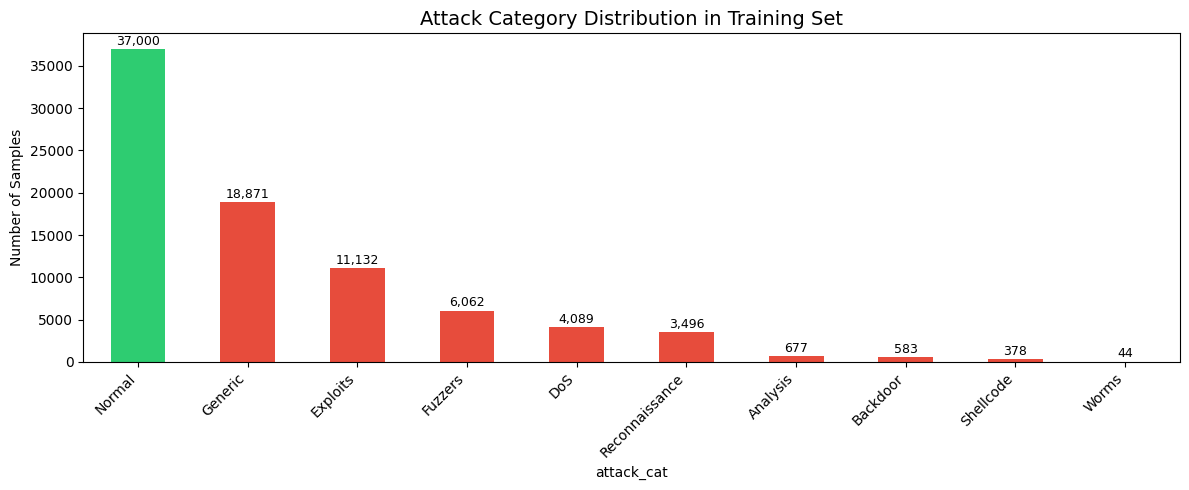

In [5]:
# ============================================================
# CELL 5: Attack category distribution
# ============================================================

print("=" * 60)
print("ATTACK CATEGORY DISTRIBUTION (Training Set)")
print("=" * 60)

# Clean the attack_cat column first
train_df['attack_cat'] = train_df['attack_cat'].fillna('Normal').str.strip()
test_df['attack_cat']  = test_df['attack_cat'].fillna('Normal').str.strip()

# Fix: where label=0, attack_cat should be 'Normal'
train_df.loc[train_df['label'] == 0, 'attack_cat'] = 'Normal'
test_df.loc[test_df['label'] == 0, 'attack_cat'] = 'Normal'

# Print distribution
attack_dist = train_df['attack_cat'].value_counts()
print(attack_dist)
print(f"\nTotal samples: {len(train_df):,}")
print(f"Normal:        {attack_dist.get('Normal', 0):,} ({attack_dist.get('Normal', 0)/len(train_df)*100:.1f}%)")
print(f"Attack:        {len(train_df) - attack_dist.get('Normal', 0):,} ({(1 - attack_dist.get('Normal', 0)/len(train_df))*100:.1f}%)")

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
attack_dist.plot(kind='bar', ax=ax, color=['#2ecc71' if x == 'Normal' else '#e74c3c' for x in attack_dist.index])
ax.set_title('Attack Category Distribution in Training Set', fontsize=14)
ax.set_ylabel('Number of Samples')
plt.xticks(rotation=45, ha='right')
for i, v in enumerate(attack_dist.values):
    ax.text(i, v + 500, f'{v:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

In [6]:
# ============================================================
# CELL 6: Clean data and engineer features
# ============================================================

# 1. Drop the 'id' column (it's just a row index, not a feature)
train_df = train_df.drop(columns=['id'], errors='ignore')
test_df  = test_df.drop(columns=['id'], errors='ignore')

# 2. Define feature columns (everything except labels)
exclude_cols = ['label', 'attack_cat']
feature_cols = [c for c in train_df.columns if c not in exclude_cols]

# 3. Identify column types
categorical_cols = train_df[feature_cols].select_dtypes(include=['object']).columns.tolist()
numerical_cols   = [c for c in feature_cols if c not in categorical_cols]

print(f"Total features:       {len(feature_cols)}")
print(f"Categorical features: {len(categorical_cols)} → {categorical_cols}")
print(f"Numerical features:   {len(numerical_cols)}")

# 4. Handle missing values
missing_before = train_df[feature_cols].isnull().sum().sum()
train_df[feature_cols] = train_df[feature_cols].fillna(0)
test_df[feature_cols]  = test_df[feature_cols].fillna(0)
print(f"\nMissing values (train): {missing_before} → {train_df[feature_cols].isnull().sum().sum()}")

# 5. Encode categorical features
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    # Fit on combined data to handle unseen categories
    combined = pd.concat([train_df[col].astype(str), test_df[col].astype(str)])
    le.fit(combined)
    train_df[col] = le.transform(train_df[col].astype(str))
    test_df[col]  = le.transform(test_df[col].astype(str))
    label_encoders[col] = le
    print(f"  Encoded '{col}': {len(le.classes_)} unique values")

# 6. Normalize numerical features
scaler = StandardScaler()
train_df[numerical_cols] = scaler.fit_transform(train_df[numerical_cols])
test_df[numerical_cols]  = scaler.transform(test_df[numerical_cols])
print(f"\nNormalized {len(numerical_cols)} numerical features (mean=0, std=1)")

# 7. Encode target labels
attack_encoder = LabelEncoder()
train_df['attack_label'] = attack_encoder.fit_transform(train_df['attack_cat'])
test_df['attack_label']  = attack_encoder.transform(test_df['attack_cat'])
num_classes = len(attack_encoder.classes_)

print(f"\nTarget classes ({num_classes}):")
for i, cls in enumerate(attack_encoder.classes_):
    count = (train_df['attack_label'] == i).sum()
    print(f"  {i}: {cls:20s} → {count:,} samples")

Total features:       42
Categorical features: 3 → ['proto', 'service', 'state']
Numerical features:   39

Missing values (train): 0 → 0
  Encoded 'proto': 133 unique values
  Encoded 'service': 13 unique values
  Encoded 'state': 11 unique values

Normalized 39 numerical features (mean=0, std=1)

Target classes (10):
  0: Analysis             → 677 samples
  1: Backdoor             → 583 samples
  2: DoS                  → 4,089 samples
  3: Exploits             → 11,132 samples
  4: Fuzzers              → 6,062 samples
  5: Generic              → 18,871 samples
  6: Normal               → 37,000 samples
  7: Reconnaissance       → 3,496 samples
  8: Shellcode            → 378 samples
  9: Worms                → 44 samples


In [7]:
# ============================================================
# CELL 7: Create sliding window sequences for Mamba
# ============================================================

class NIDSSequenceDataset(Dataset):
    """
    Converts tabular network flows into sequences using a sliding window.
    Each sample = a window of `seq_len` consecutive flows.
    Label = the LAST flow's label (predict current based on past context).
    """
    def __init__(self, dataframe, feature_cols, label_col, seq_len=32, stride=1):
        self.seq_len = seq_len
        self.features = dataframe[feature_cols].values.astype(np.float32)
        self.labels   = dataframe[label_col].values.astype(np.int64)
        self.stride   = stride
        self.valid_indices = list(range(0, len(self.features) - seq_len + 1, stride))
    
    def __len__(self):
        return len(self.valid_indices)
    
    def __getitem__(self, idx):
        start = self.valid_indices[idx]
        end   = start + self.seq_len
        x = torch.tensor(self.features[start:end])   # (seq_len, num_features)
        y = torch.tensor(self.labels[end - 1])        # label of last flow
        return x, y

# Hyperparameters
SEQ_LEN    = 32     # look at 32 consecutive flows
BATCH_SIZE = 64     # process 64 sequences at once
STRIDE     = 4      # slide the window by 4 each time (reduces dataset size, speeds up training)

# Create datasets
train_dataset = NIDSSequenceDataset(train_df, feature_cols, 'attack_label', seq_len=SEQ_LEN, stride=STRIDE)
test_dataset  = NIDSSequenceDataset(test_df,  feature_cols, 'attack_label', seq_len=SEQ_LEN, stride=STRIDE)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# Verify shapes
sample_x, sample_y = train_dataset[0]
print(f"Sequence length:     {SEQ_LEN}")
print(f"Stride:              {STRIDE}")
print(f"Feature dimension:   {len(feature_cols)}")
print(f"Number of classes:   {num_classes}")
print(f"")
print(f"Training sequences:  {len(train_dataset):,}")
print(f"Testing sequences:   {len(test_dataset):,}")
print(f"Training batches:    {len(train_loader):,}")
print(f"Testing batches:     {len(test_loader):,}")
print(f"")
print(f"Single sample shape: x={sample_x.shape}, y={sample_y.shape}")
print(f"  x dtype: {sample_x.dtype}")
print(f"  y value: {sample_y.item()} ({attack_encoder.classes_[sample_y.item()]})")

Sequence length:     32
Stride:              4
Feature dimension:   42
Number of classes:   10

Training sequences:  20,576
Testing sequences:   43,828
Training batches:    322
Testing batches:     685

Single sample shape: x=torch.Size([32, 42]), y=torch.Size([])
  x dtype: torch.float32
  y value: 6 (Normal)


In [8]:
# ============================================================
# CELL 8: Define the model (with automatic fallback)
# ============================================================

USING_MAMBA_SSM = False

try:
    from mamba_ssm import Mamba
    USING_MAMBA_SSM = True
    print("✅ mamba-ssm library loaded successfully! Using GPU-accelerated Mamba.")
    
    class MambaNIDS(nn.Module):
        def __init__(self, input_dim, d_model=64, d_state=16, d_conv=4,
                     expand=2, n_layers=4, num_classes=10, dropout=0.1):
            super().__init__()
            self.input_proj = nn.Linear(input_dim, d_model)
            
            self.layers = nn.ModuleList()
            self.norms  = nn.ModuleList()
            for _ in range(n_layers):
                self.layers.append(
                    Mamba(d_model=d_model, d_state=d_state, d_conv=d_conv, expand=expand)
                )
                self.norms.append(nn.LayerNorm(d_model))
            
            self.dropout = nn.Dropout(dropout)
            self.classifier = nn.Sequential(
                nn.Linear(d_model, d_model),
                nn.GELU(),
                nn.Dropout(dropout),
                nn.Linear(d_model, num_classes)
            )
        
        def forward(self, x):
            x = self.input_proj(x)
            for mamba_layer, norm in zip(self.layers, self.norms):
                residual = x
                x = norm(x)
                x = mamba_layer(x)
                x = x + residual
            x = x.mean(dim=1)
            x = self.dropout(x)
            return self.classifier(x)

except ImportError:
    print("⚠️  mamba-ssm not available. Using pure PyTorch SSM fallback.")
    print("   (This is functionally identical, just slower during training)")
    
    class SelectiveSSM(nn.Module):
        def __init__(self, d_model, d_state=16, d_conv=4, expand=2):
            super().__init__()
            d_inner = d_model * expand
            self.in_proj = nn.Linear(d_model, d_inner * 2, bias=False)
            self.conv1d = nn.Conv1d(d_inner, d_inner, kernel_size=d_conv,
                                    padding=d_conv - 1, groups=d_inner)
            self.x_proj  = nn.Linear(d_inner, d_state * 2 + 1, bias=False)
            self.dt_proj = nn.Linear(1, d_inner, bias=True)
            A = torch.arange(1, d_state + 1, dtype=torch.float32).unsqueeze(0).expand(d_inner, -1)
            self.A_log = nn.Parameter(torch.log(A))
            self.D = nn.Parameter(torch.ones(d_inner))
            self.out_proj = nn.Linear(d_inner, d_model, bias=False)
            self.d_inner = d_inner
            self.d_state = d_state
        
        def forward(self, x):
            batch, seq_len, _ = x.shape
            xz = self.in_proj(x)
            x_branch, z = xz.chunk(2, dim=-1)
            x_conv = x_branch.transpose(1, 2)
            x_conv = self.conv1d(x_conv)[:, :, :seq_len]
            x_branch = torch.nn.functional.silu(x_conv.transpose(1, 2))
            x_proj = self.x_proj(x_branch)
            B = x_proj[:, :, :self.d_state]
            C = x_proj[:, :, self.d_state:2*self.d_state]
            delta = torch.nn.functional.softplus(x_proj[:, :, -1:])
            delta = self.dt_proj(delta)
            A = -torch.exp(self.A_log)
            h = torch.zeros(batch, self.d_inner, self.d_state, device=x.device)
            outputs = []
            for t in range(seq_len):
                dt = delta[:, t, :]
                A_bar = torch.exp(dt.unsqueeze(-1) * A.unsqueeze(0))
                B_bar = dt.unsqueeze(-1) * B[:, t, :].unsqueeze(1)
                h = A_bar * h + B_bar * x_branch[:, t, :].unsqueeze(-1)
                y_t = (h * C[:, t, :].unsqueeze(1)).sum(dim=-1) + self.D * x_branch[:, t, :]
                outputs.append(y_t)
            y = torch.stack(outputs, dim=1)
            z = torch.nn.functional.silu(z)
            return self.out_proj(y * z)
    
    class MambaNIDS(nn.Module):
        def __init__(self, input_dim, d_model=64, d_state=16, d_conv=4,
                     expand=2, n_layers=4, num_classes=10, dropout=0.1):
            super().__init__()
            self.input_proj = nn.Linear(input_dim, d_model)
            self.layers = nn.ModuleList()
            self.norms  = nn.ModuleList()
            for _ in range(n_layers):
                self.layers.append(SelectiveSSM(d_model, d_state, d_conv, expand))
                self.norms.append(nn.LayerNorm(d_model))
            self.dropout = nn.Dropout(dropout)
            self.classifier = nn.Sequential(
                nn.Linear(d_model, d_model), nn.GELU(),
                nn.Dropout(dropout), nn.Linear(d_model, num_classes))
        
        def forward(self, x):
            x = self.input_proj(x)
            for layer, norm in zip(self.layers, self.norms):
                residual = x
                x = norm(x)
                x = layer(x)
                x = x + residual
            x = x.mean(dim=1)
            x = self.dropout(x)
            return self.classifier(x)

# ─── Instantiate the model ───
INPUT_DIM   = len(feature_cols)  # 42
D_MODEL     = 64
D_STATE     = 16
N_LAYERS    = 4
NUM_CLASSES = num_classes        # 10
DROPOUT     = 0.1

model = MambaNIDS(
    input_dim=INPUT_DIM, d_model=D_MODEL, d_state=D_STATE,
    n_layers=N_LAYERS, num_classes=NUM_CLASSES, dropout=DROPOUT
).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n{'='*60}")
print(f"MODEL SUMMARY")
print(f"{'='*60}")
print(f"Architecture:       MambaNIDS ({'mamba-ssm GPU' if USING_MAMBA_SSM else 'PyTorch fallback'})")
print(f"Input dimension:    {INPUT_DIM}")
print(f"Model dimension:    {D_MODEL}")
print(f"SSM state size:     {D_STATE}")
print(f"Number of layers:   {N_LAYERS}")
print(f"Number of classes:  {NUM_CLASSES}")
print(f"Total parameters:   {total_params:,}")
print(f"Trainable params:   {trainable_params:,}")
print(f"Model size:         {total_params * 4 / 1024:.1f} KB (float32)")
print(f"Device:             {device}")

✅ mamba-ssm library loaded successfully! Using GPU-accelerated Mamba.

MODEL SUMMARY
Architecture:       MambaNIDS (mamba-ssm GPU)
Input dimension:    42
Model dimension:    64
SSM state size:     16
Number of layers:   4
Number of classes:  10
Total parameters:   138,634
Trainable params:   138,634
Model size:         541.5 KB (float32)
Device:             cuda


In [9]:
# ============================================================
# CELL 9: Handle class imbalance with weighted loss
# ============================================================

class_weights = compute_class_weight(
    'balanced',
    classes=np.arange(num_classes),
    y=train_df['attack_label'].values
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

print("Class weights (higher = rarer class, gets more importance):")
print("-" * 50)
for i, (cls, w) in enumerate(zip(attack_encoder.classes_, class_weights)):
    count = (train_df['attack_label'] == i).sum()
    print(f"  {cls:20s}  weight={w:8.4f}  (n={count:,})")

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
print(f"\n✅ Using weighted CrossEntropyLoss")

Class weights (higher = rarer class, gets more importance):
--------------------------------------------------
  Analysis              weight= 12.1613  (n=677)
  Backdoor              weight= 14.1221  (n=583)
  DoS                   weight=  2.0135  (n=4,089)
  Exploits              weight=  0.7396  (n=11,132)
  Fuzzers               weight=  1.3582  (n=6,062)
  Generic               weight=  0.4363  (n=18,871)
  Normal                weight=  0.2225  (n=37,000)
  Reconnaissance        weight=  2.3550  (n=3,496)
  Shellcode             weight= 21.7810  (n=378)
  Worms                 weight=187.1182  (n=44)

✅ Using weighted CrossEntropyLoss


In [10]:
# ============================================================
# CELL 10: Train the model
# ============================================================

LR     = 1e-3
EPOCHS = 30

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
        _, pred = logits.max(1)
        total   += y.size(0)
        correct += pred.eq(y).sum().item()
    return total_loss / len(loader), 100.0 * correct / total

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        total_loss += loss.item()
        _, pred = logits.max(1)
        total   += y.size(0)
        correct += pred.eq(y).sum().item()
        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(y.cpu().numpy())
    return total_loss / len(loader), 100.0 * correct / total, all_preds, all_labels

# ─── Training ───
print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Train Acc':>9} | {'Test Loss':>9} | {'Test Acc':>8} | {'LR':>10}")
print("-" * 75)

best_acc = 0
history = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}

for epoch in range(1, EPOCHS + 1):
    t_start = time.time()
    
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    test_loss, test_acc, preds, labels = evaluate(model, test_loader, criterion)
    scheduler.step()
    
    elapsed = time.time() - t_start
    lr_now = optimizer.param_groups[0]['lr']
    
    history['train_loss'].append(train_loss)
    history['test_loss'].append(test_loss)
    history['train_acc'].append(train_acc)
    history['test_acc'].append(test_acc)
    
    marker = ""
    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), 'best_mamba_nids.pth')
        marker = " ★ saved"
    
    print(f"{epoch:5d} | {train_loss:10.4f} | {train_acc:8.2f}% | {test_loss:9.4f} | {test_acc:7.2f}% | {lr_now:.2e} ({elapsed:.1f}s){marker}")

print(f"\n{'='*60}")
print(f"Training complete! Best test accuracy: {best_acc:.2f}%")
print(f"Model saved to: best_mamba_nids.pth")

Epoch | Train Loss | Train Acc | Test Loss | Test Acc |         LR
---------------------------------------------------------------------------
    1 |     2.1229 |    43.30% |   32.7214 |   62.30% | 9.97e-04 (10.4s) ★ saved
    2 |     1.9071 |    60.64% |   12.9081 |   43.32% | 9.89e-04 (9.3s)
    3 |     1.8501 |    62.95% |   10.2669 |   54.82% | 9.76e-04 (9.0s)
    4 |     1.8087 |    64.41% |    6.1488 |   45.81% | 9.57e-04 (8.8s)
    5 |     1.7788 |    63.96% |    4.9965 |   57.00% | 9.33e-04 (9.0s)
    6 |     1.7606 |    65.21% |    3.5171 |   51.83% | 9.05e-04 (9.1s)
    7 |     1.7309 |    66.10% |    4.5082 |   55.89% | 8.72e-04 (9.1s)
    8 |     1.7154 |    66.78% |    3.3224 |   51.78% | 8.35e-04 (9.2s)
    9 |     1.7029 |    66.68% |    7.3785 |   55.69% | 7.94e-04 (8.9s)
   10 |     1.7023 |    67.27% |    3.9665 |   53.66% | 7.50e-04 (8.9s)
   11 |     1.6480 |    67.90% |    8.5618 |   53.81% | 7.03e-04 (9.0s)
   12 |     1.6343 |    68.35% |    4.7874 |   58.97% | 

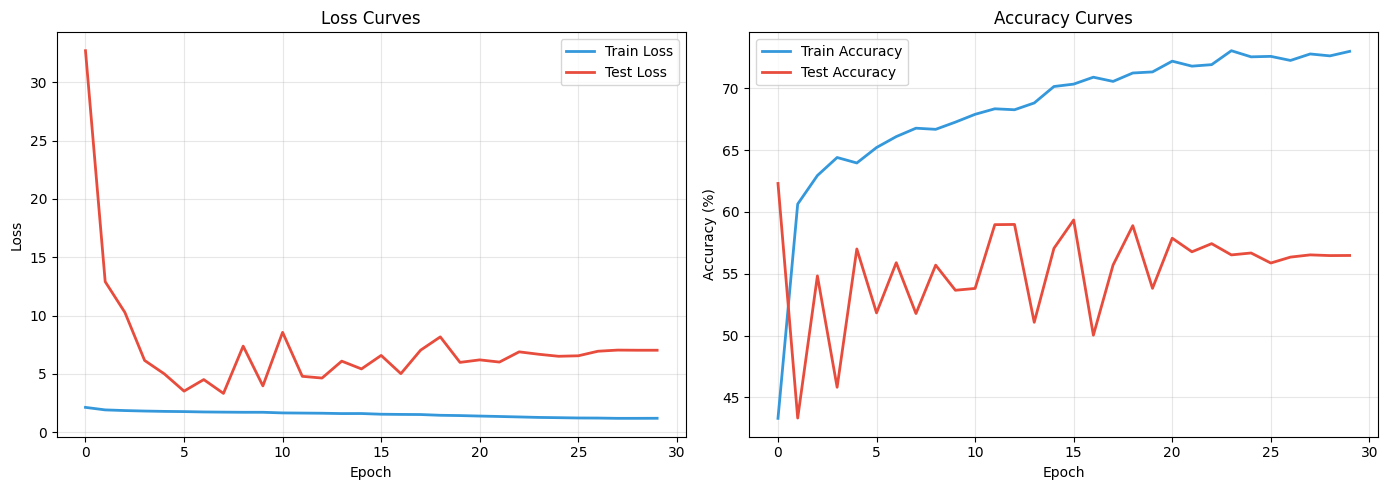

Saved: training_curves.png


In [11]:
# ============================================================
# CELL 11: Visualize training progress
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
ax1.plot(history['train_loss'], label='Train Loss', color='#3498db', linewidth=2)
ax1.plot(history['test_loss'],  label='Test Loss',  color='#e74c3c', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss Curves')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy curves
ax2.plot(history['train_acc'], label='Train Accuracy', color='#3498db', linewidth=2)
ax2.plot(history['test_acc'],  label='Test Accuracy',  color='#e74c3c', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Accuracy Curves')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: training_curves.png")

CLASSIFICATION REPORT — Mamba NIDS
                precision    recall  f1-score   support

      Analysis     0.0397    0.0102    0.0162       491
      Backdoor     0.0286    0.0276    0.0281       435
           DoS     0.1932    0.2556    0.2201      3102
      Exploits     0.3859    0.4820    0.4287      8244
       Fuzzers     0.2458    0.0702    0.1092      4631
       Generic     0.7100    0.9896    0.8268      9991
        Normal     0.9035    0.8776    0.8904     14028
Reconnaissance     0.0000    0.0000    0.0000      2585
     Shellcode     0.0000    0.0000    0.0000       283
         Worms     0.0000    0.0000    0.0000        38

      accuracy                         0.6230     43828
     macro avg     0.2507    0.2713    0.2519     43828
  weighted avg     0.5640    0.6230    0.5817     43828

Macro F1-Score:    0.2519
Weighted F1-Score: 0.5817
Overall Accuracy:  62.30%


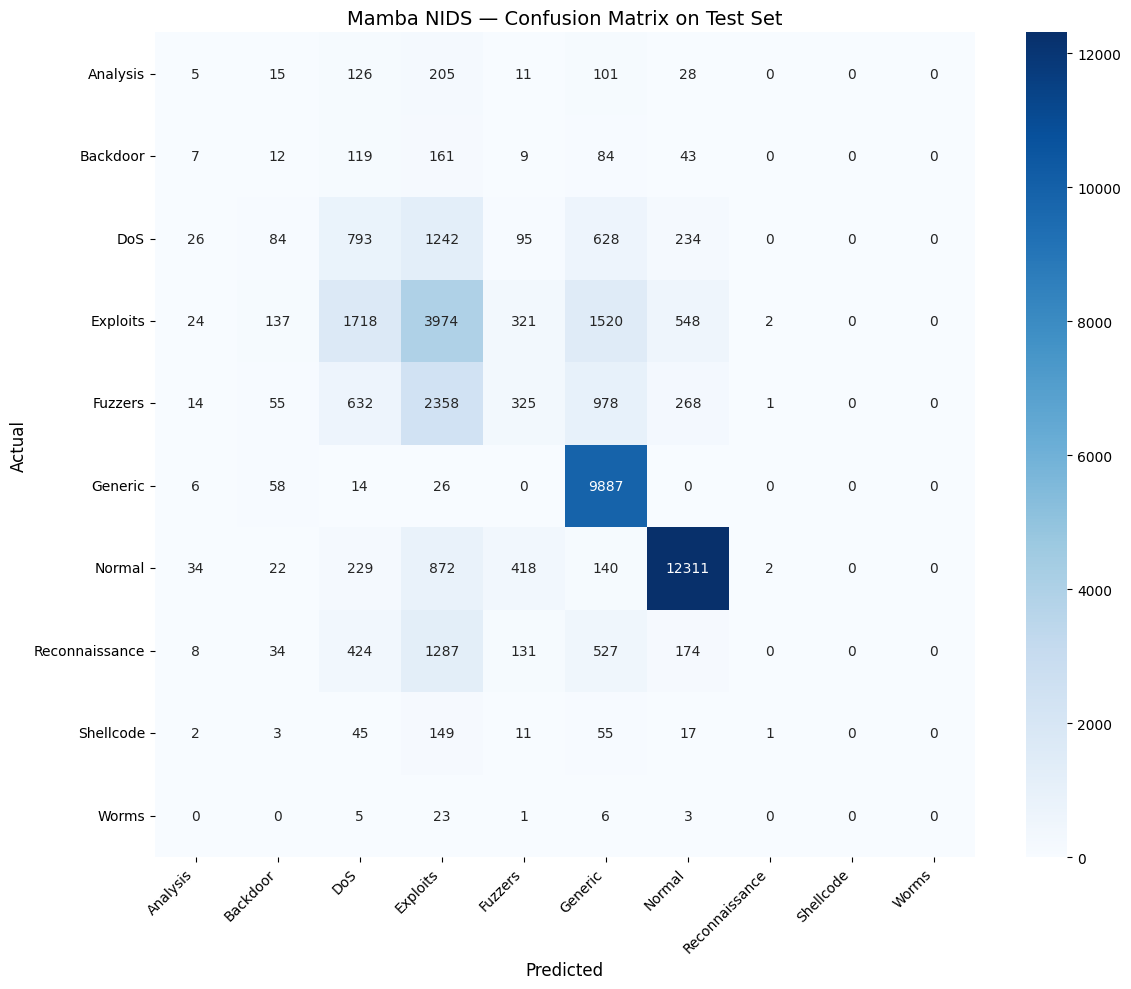

Saved: confusion_matrix.png


In [12]:
# ============================================================
# CELL 12: Full evaluation on test set
# ============================================================

# Load best model
model.load_state_dict(torch.load('best_mamba_nids.pth'))
_, test_acc, preds, labels = evaluate(model, test_loader, criterion)

# Classification Report
print("=" * 70)
print("CLASSIFICATION REPORT — Mamba NIDS")
print("=" * 70)
print(classification_report(labels, preds, target_names=attack_encoder.classes_, digits=4))

# Key metrics
macro_f1    = f1_score(labels, preds, average='macro')
weighted_f1 = f1_score(labels, preds, average='weighted')
print(f"Macro F1-Score:    {macro_f1:.4f}")
print(f"Weighted F1-Score: {weighted_f1:.4f}")
print(f"Overall Accuracy:  {test_acc:.2f}%")

# Confusion Matrix
cm = confusion_matrix(labels, preds)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=attack_encoder.classes_,
            yticklabels=attack_encoder.classes_)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Mamba NIDS — Confusion Matrix on Test Set', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: confusion_matrix.png")

In [13]:
# ============================================================
# CELL 13: Baseline models for comparison
# ============================================================

# Prepare FLAT data (non-sequential — baselines don't use sequences)
X_train_flat = train_df[feature_cols].values
y_train_flat = train_df['attack_label'].values
X_test_flat  = test_df[feature_cols].values
y_test_flat  = test_df['attack_label'].values

print(f"Flat data shapes: X_train={X_train_flat.shape}, X_test={X_test_flat.shape}")

# ─── Random Forest ───
print("\n" + "=" * 60)
print("RANDOM FOREST")
print("=" * 60)
t0 = time.time()
rf = RandomForestClassifier(n_estimators=100, max_depth=20, n_jobs=-1,
                             class_weight='balanced', random_state=42)
rf.fit(X_train_flat, y_train_flat)
rf_train_time = time.time() - t0

t0 = time.time()
rf_preds = rf.predict(X_test_flat)
rf_infer_time = time.time() - t0

rf_acc = (rf_preds == y_test_flat).mean() * 100
rf_f1  = f1_score(y_test_flat, rf_preds, average='macro')
print(f"Training time:   {rf_train_time:.1f}s")
print(f"Inference time:  {rf_infer_time:.1f}s (for {len(y_test_flat):,} samples)")
print(f"Per-sample time: {rf_infer_time/len(y_test_flat)*1000:.4f} ms")
print(f"Accuracy:        {rf_acc:.2f}%")
print(f"Macro F1-Score:  {rf_f1:.4f}")

# ─── XGBoost ───
print("\n" + "=" * 60)
print("XGBOOST")
print("=" * 60)
from xgboost import XGBClassifier

t0 = time.time()
xgb = XGBClassifier(n_estimators=200, max_depth=8, learning_rate=0.1,
                     tree_method='hist', device='cuda',    # ← changed these two
                     eval_metric='mlogloss', random_state=42,
                     use_label_encoder=False)
xgb.fit(X_train_flat, y_train_flat, verbose=False)
xgb_train_time = time.time() - t0

t0 = time.time()
xgb_preds = xgb.predict(X_test_flat)
xgb_infer_time = time.time() - t0

xgb_acc = (xgb_preds == y_test_flat).mean() * 100
xgb_f1  = f1_score(y_test_flat, xgb_preds, average='macro')
print(f"Training time:   {xgb_train_time:.1f}s")
print(f"Inference time:  {xgb_infer_time:.1f}s (for {len(y_test_flat):,} samples)")
print(f"Per-sample time: {xgb_infer_time/len(y_test_flat)*1000:.4f} ms")
print(f"Accuracy:        {xgb_acc:.2f}%")
print(f"Macro F1-Score:  {xgb_f1:.4f}")

Flat data shapes: X_train=(82332, 42), X_test=(175341, 42)

RANDOM FOREST
Training time:   6.6s
Inference time:  0.9s (for 175,341 samples)
Per-sample time: 0.0052 ms
Accuracy:        75.22%
Macro F1-Score:  0.5259

XGBOOST
Training time:   6.2s
Inference time:  0.4s (for 175,341 samples)
Per-sample time: 0.0021 ms
Accuracy:        76.25%
Macro F1-Score:  0.5338


In [14]:
# ============================================================
# CELL 14: Benchmark Mamba inference speed and memory
# ============================================================

model.eval()
dummy_input = torch.randn(1, SEQ_LEN, INPUT_DIM).to(device)

# Warm up GPU
for _ in range(20):
    with torch.no_grad():
        _ = model(dummy_input)
torch.cuda.synchronize()

# Speed benchmark
times = []
for _ in range(200):
    torch.cuda.synchronize()
    t0 = time.perf_counter()
    with torch.no_grad():
        _ = model(dummy_input)
    torch.cuda.synchronize()
    times.append(time.perf_counter() - t0)

print("=" * 60)
print("MAMBA NIDS — INFERENCE SPEED (single sequence)")
print("=" * 60)
print(f"  Mean:   {np.mean(times)*1000:.3f} ms")
print(f"  Median: {np.median(times)*1000:.3f} ms")
print(f"  Std:    {np.std(times)*1000:.3f} ms")
print(f"  Min:    {np.min(times)*1000:.3f} ms")
print(f"  Max:    {np.max(times)*1000:.3f} ms")

# Memory benchmark
torch.cuda.reset_peak_memory_stats()
with torch.no_grad():
    _ = model(dummy_input)
peak_gpu_mem = torch.cuda.max_memory_allocated() / 1024 / 1024

print(f"\n{'='*60}")
print("MAMBA NIDS — GPU MEMORY USAGE")
print("=" * 60)
print(f"  Peak GPU memory (inference): {peak_gpu_mem:.2f} MB")
print(f"  Model size on disk:          {os.path.getsize('best_mamba_nids.pth') / 1024:.1f} KB")

# Compare: what a Transformer would need (theoretical)
transformer_attention_mem = SEQ_LEN * SEQ_LEN * 8 * 4 / 1024 / 1024  # 8 heads, float32
print(f"\n  For comparison (theoretical):")
print(f"  Transformer attention matrix at seq_len={SEQ_LEN}: {transformer_attention_mem:.2f} MB per layer")
print(f"  Mamba state at seq_len={SEQ_LEN}: {D_MODEL * 2 * D_STATE * 4 / 1024:.2f} KB per layer")
print(f"  → Mamba uses ~{transformer_attention_mem * 1024 / (D_MODEL * 2 * D_STATE * 4 / 1024):.0f}× less memory per layer")

MAMBA NIDS — INFERENCE SPEED (single sequence)
  Mean:   3.028 ms
  Median: 3.007 ms
  Std:    0.167 ms
  Min:    2.845 ms
  Max:    4.441 ms

MAMBA NIDS — GPU MEMORY USAGE
  Peak GPU memory (inference): 19.52 MB
  Model size on disk:          559.0 KB

  For comparison (theoretical):
  Transformer attention matrix at seq_len=32: 0.03 MB per layer
  Mamba state at seq_len=32: 8.00 KB per layer
  → Mamba uses ~4× less memory per layer


In [15]:
# ============================================================
# CELL 15: Final comparison + download model
# ============================================================

print("=" * 80)
print("FINAL COMPARISON TABLE")
print("=" * 80)

mamba_infer_ms = np.median(times) * 1000

comparison = pd.DataFrame({
    'Model':              ['Random Forest', 'XGBoost', 'Mamba NIDS (Ours)'],
    'Accuracy (%)':       [f'{rf_acc:.2f}', f'{xgb_acc:.2f}', f'{test_acc:.2f}'],
    'Macro F1':           [f'{rf_f1:.4f}', f'{xgb_f1:.4f}', f'{macro_f1:.4f}'],
    'Weighted F1':        ['-', '-', f'{weighted_f1:.4f}'],
    'Inference (ms)':     [f'{rf_infer_time/len(y_test_flat)*1000:.4f}',
                           f'{xgb_infer_time/len(y_test_flat)*1000:.4f}',
                           f'{mamba_infer_ms:.3f}'],
    'Parameters':         ['N/A', 'N/A', f'{total_params:,}'],
    'Temporal Patterns':  ['❌ No', '❌ No', '✅ Yes'],
    'Sequence Aware':     ['❌ No', '❌ No', '✅ Yes'],
})
print(comparison.to_string(index=False))

# Save model for download
output_dir = '/kaggle/working'
torch.save({
    'model_state_dict': model.state_dict(),
    'attack_encoder_classes': attack_encoder.classes_.tolist(),
    'feature_cols': feature_cols,
    'scaler_mean': scaler.mean_.tolist(),
    'scaler_scale': scaler.scale_.tolist(),
    'hyperparams': {
        'input_dim': INPUT_DIM, 'd_model': D_MODEL, 'd_state': D_STATE,
        'n_layers': N_LAYERS, 'num_classes': NUM_CLASSES, 'seq_len': SEQ_LEN,
    }
}, os.path.join(output_dir, 'mamba_nids_complete.pth'))

print(f"\n✅ Complete model package saved to: {output_dir}/mamba_nids_complete.pth")
print(f"   (Includes model weights, scaler parameters, class names, and hyperparameters)")
print(f"\n📥 To download: Click 'Save Version' (top-right) → then go to")
print(f"   your notebook's Output tab → download mamba_nids_complete.pth")

FINAL COMPARISON TABLE
            Model Accuracy (%) Macro F1 Weighted F1 Inference (ms) Parameters Temporal Patterns Sequence Aware
    Random Forest        75.22   0.5259           -         0.0052        N/A              ❌ No           ❌ No
          XGBoost        76.25   0.5338           -         0.0021        N/A              ❌ No           ❌ No
Mamba NIDS (Ours)        62.30   0.2519      0.5817          3.007    138,634             ✅ Yes          ✅ Yes

✅ Complete model package saved to: /kaggle/working/mamba_nids_complete.pth
   (Includes model weights, scaler parameters, class names, and hyperparameters)

📥 To download: Click 'Save Version' (top-right) → then go to
   your notebook's Output tab → download mamba_nids_complete.pth
